# Лабораторная работа №4

## Задание

По заданию выбрать свои классы, загрузить предобученную модель по варианту, заморозить веса модели и провести дообучение на своих классах набора данных. Параметры аугментации использовать из лабораторной работы номер 3.

Сравнить результаты и качество обученных моделей для первых четырех лабораторных работ.

Отчет должен содержать: титульный лист, задание с вариантом, скриншоты и краткие пояснения по каждому этапу лабораторной работы, результаты дообучения модели после заморозки весов, итоговую таблицу с результатами для всех вариантов обучения.

Варианты классов использовать из 1 лабораторной работы.

## Варианты предобученных моделей

|  Вариант   |  Модель   
| ---------- | :-------:
|  Четный    | resnet20
|  Нечетный  | mobilenetv2_x0_5

## Задания для самостоятельной работы
1. Проведите обучение модели по вашему варианту с наилучшими параметрами аугментации из предыдущей лабораторной;
2. Проанализируйте результаты обучения вашей модели. Как изменилась точность на обучающей и тестовой выборке по сравнению с предыдущими моделями?
3. Сравните обучение модели с заморозкой и без заморозки весов;
4. Измените гиперпараметры обучения для повышения точности модели: количество эпох, размер батча, скорость обучения;
5. Сравните разные варианты оптимизатора;
6. Укажите, какие действия помогли повысить точность вашей модели и объясните почему.


## Контрольные вопросы для защиты
1. Что такое перенос обучения?
2. Опишите архитектуру предобученной модели вашего варианта;
3. Что такое fine-tuning? Что такое заморозка весов?
4. Метод оптимизации Adagrad;
5. Метод оптимизации RMSProp;
6. Метод оптимизации Adam.

#Инициализация предобученной модели

In [1]:
#!pip install torchsummary
import time
import sys
import sklearn
import numpy as np
import torch
import torch.optim as optim
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, Dataset, DataLoader
from torchsummary import summary
from torchvision import transforms as T
import pickle
from sklearn.metrics import classification_report
from PIL import Image
from tqdm.auto import tqdm
from IPython.display import clear_output
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
# ========== ВЕРСИИ БИБЛИОТЕК ==========
print("=" * 50)
print("ВЕРСИИ БИБЛИОТЕК:")
print("=" * 50)

print(f"Python:          {sys.version.split()[0]}")
print(f"NumPy:           {np.__version__}")
print(f"Matplotlib:      {plt.matplotlib.__version__}")
print(f"Pillow:          {Image.__version__}")
print(f"Scikit-learn:    {sklearn.__version__}")
print(f"PyTorch:         {torch.__version__}")
print(f"  └─ CUDA:       {torch.version.cuda if torch.cuda.is_available() else 'не доступен'}")
print(f"  └─ cuDNN:      {torch.backends.cudnn.version() if torch.cuda.is_available() else 'не доступен'}")
print("=" * 50)

ВЕРСИИ БИБЛИОТЕК:
Python:          3.12.13
NumPy:           2.0.2
Matplotlib:      3.10.0
Pillow:          11.3.0
Scikit-learn:    1.6.1
PyTorch:         2.11.0+cu128
  └─ CUDA:       12.8
  └─ cuDNN:      91900


Актуально для среды выполнения Colab v2026.4 (сменить среду выполнения -> Версия среды выполнения)
- Python:          3.12.13
- NumPy:           2.0.2
- Matplotlib:      3.10.0
- Pillow:          11.3.0
- Scikit-learn:    1.6.1
- PyTorch:         2.11.0+cpu
-  └─ CUDA:       12.8
-  └─ cuDNN:      91900

In [2]:
!nvidia-smi

Mon Jun 22 08:45:22 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   46C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [4]:
# Использовать ли зеркало 'Kaggle' для загрузки
DOWNLOAD_FROM_KAGGLE = True
DATASET_PATH = 'cifar-100-python/train'

if DOWNLOAD_FROM_KAGGLE:
  import os
  import kagglehub

  # Download latest version
  path = kagglehub.dataset_download("fedesoriano/cifar100")

  print("Path to dataset files:", path)

  # Посмотрим, что там внутри
  print("Файлы в папке:", os.listdir(path))

  # Если там папка cifar-100-python
  if "cifar-100-python" in os.listdir(path):
      data_path = os.path.join(path, "cifar-100-python")
  else:
      data_path = path

  # Загружаем данные напрямую
  with open(os.path.join(data_path, 'train'), 'rb') as f:
      data_train = pickle.load(f, encoding='latin1')

  with open(os.path.join(data_path, 'test'), 'rb') as f:
      data_test = pickle.load(f, encoding='latin1')

  print("Train keys:", data_train.keys())
  print("Test keys:", data_test.keys())

  DATASET_PATH = path # "/root/.cache/kagglehub/datasets/fedesoriano/cifar100/versions/1"

else:
  !wget https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz
  !tar -xvzf cifar-100-python.tar.gz

Using Colab cache for faster access to the 'cifar100' dataset.
Path to dataset files: /kaggle/input/cifar100
Файлы в папке: ['meta', 'file.txt', 'test', 'train']
Train keys: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])
Test keys: dict_keys(['filenames', 'batch_label', 'fine_labels', 'coarse_labels', 'data'])


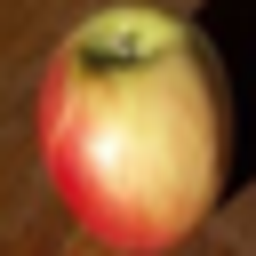

In [5]:
# Здесь указать ваши классы по варианту!!!
CLASSES = [0, 55, 58]


# Обучающая выборка
# with open('cifar-100-python/train', 'rb') as f:
#     data_train = pickle.load(f, encoding='latin1')
with open(os.path.join(DATASET_PATH, 'train'), 'rb') as f:
    data_train = pickle.load(f, encoding='latin1')


train_y = np.array(data_train['fine_labels'])
mask = np.isin(train_y, CLASSES)

# Сначала фильтруем данные (работаем с плоским массивом)
train_y_filtered = train_y[mask].copy()
train_X_flat = data_train['data'][mask].copy()

# Теперь преобразуем в формат NCHW (каналы-первыми) — нативный для PyTorch
train_X = train_X_flat.reshape(-1, 3, 32, 32)  # (N, 3, 32, 32) — NCHW
# Для визуализации будем использовать np.transpose на месте
# train_X_nhwc = np.transpose(train_X, [0, 2, 3, 1]) — делаем только при отрисовке

# Перекодируем метки в 0, 1, 2
train_y = np.unique(train_y_filtered, return_inverse=1)[1]
del data_train, train_y_filtered, train_X_flat


# Тестовая выборка (аналогично)
# with open('cifar-100-python/test', 'rb') as f:
#     data_test = pickle.load(f, encoding='latin1')
with open(os.path.join(DATASET_PATH, 'test'), 'rb') as f:
    data_test = pickle.load(f, encoding='latin1')

test_y = np.array(data_test['fine_labels'])
mask = np.isin(test_y, CLASSES)

test_y_filtered = test_y[mask].copy()
test_X_flat = data_test['data'][mask].copy()

test_X = test_X_flat.reshape(-1, 3, 32, 32)  # (N, 3, 32, 32) — NCHW

test_y = np.unique(test_y_filtered, return_inverse=1)[1]
del data_test, test_y_filtered, test_X_flat


# Для отображения изображения временно меняем порядок осей NCHW → NHWC
Image.fromarray(np.transpose(train_X[50], [1, 2, 0])).resize((256, 256))

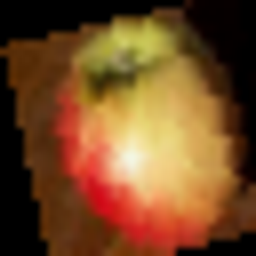

In [6]:
class CifarDataset(Dataset):
    """
    Датасет для CIFAR-100 с поддержкой аугментации.

    Особенности:
    - Работает с данными в формате NCHW (каналы-первыми) - нативно для PyTorch
    - Аугментация применяется с вероятностью self.prob
    - Применяет transform к нормализованному изображению (значения 0..1)
    """
    def __init__(self, X, y, transform=None, p=0.0):
        assert X.size(0) == y.size(0), "X и y должны иметь одинаковое количество элементов"
        super(Dataset, self).__init__()
        self.X = X
        self.y = y
        self.transform = transform
        self.prob = p

    def __len__(self):
        return self.y.size(0)

    def __getitem__(self, index):
        x = self.X[index]  # (3, 32, 32) — NCHW

        # Если задана аугментация и сработала вероятность
        if self.transform and np.random.random() < self.prob:
            x = self.transform(x)

        y = self.y[index]
        return x, y

# Аугментация
transform = T.Compose([
     T.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.2, hue=0.0),
     T.RandomAffine(degrees=15, translate=(0.1, 0.1), scale=(0.8, 1.2),
                    shear=5),
])
#transform = T.AutoAugment(T.AutoAugmentPolicy.CIFAR10)

augmented = transform(
    torch.tensor(train_X[50], dtype=torch.float32) / 255.0
).permute(1, 2, 0) * 255.0  # NCHW - NHWC, обратно к значениям 0..255
Image.fromarray(augmented.numpy().astype(np.uint8)).resize((256, 256))

In [7]:
batch_size = 128
dataloader = {}

for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    # Данные уже в формате NCHW (каналы-первыми) — нативном для PyTorch
    tensor_x = torch.Tensor(X)  # (N, 3, 32, 32)

    # One-hot кодировка для меток
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                         num_classes=len(CLASSES)).float()  # .float() вместо /1.

    # Используем наш класс датасета
    dataset = CifarDataset(tensor_x, tensor_y,
                           transform if part=='train' else None,
                           p=0.5)
    # Создание продвинутого DataLoader
    dataloader[part] = DataLoader(dataset, batch_size=batch_size,
                                  prefetch_factor=8 if part=='train' else 2,
                                  num_workers=2, persistent_workers=True,
                                  shuffle=True)

dataloader

{'train': <torch.utils.data.dataloader.DataLoader at 0x7d4bfd21cb90>,
 'test': <torch.utils.data.dataloader.DataLoader at 0x7d4bf04745f0>}

In [8]:
# Пересчитываем mean и std для нашей выборки
train_X_nchw = train_X  # уже NCHW
custom_mean = train_X_nchw.mean(axis=(0, 2, 3)).astype(np.float32) / 255.0
custom_std = train_X_nchw.std(axis=(0, 2, 3)).astype(np.float32) / 255.0

print(f"Пересчитанные mean: {custom_mean}")
print(f"Пересчитанные std: {custom_std}")

Пересчитанные mean: [0.53117317 0.4788335  0.4321059 ]
Пересчитанные std: [0.26935863 0.27282682 0.27894792]


In [19]:
class Normalize(nn.Module):
    def __init__(self, mean, std):
        super(Normalize, self).__init__()
        self.register_buffer('mean', torch.tensor(mean, dtype=torch.float32).view(-1, 1, 1))
        self.register_buffer('std', torch.tensor(std, dtype=torch.float32).view(-1, 1, 1))

    def forward(self, input):
        x = input / 255.0
        x = x - self.mean
        x = x / self.std
        return x

# Вместо собственной модели загружаем предобученную
# model = Cifar100_CNN(...)
model = torch.hub.load("chenyaofo/pytorch-cifar-models",
                       "cifar100_mobilenetv2_x0_5",
                       #"cifar100_resnet20",
                       pretrained=True)
model.to(device)
# https://blog.jovian.ai/image-classification-of-cifar100-dataset-using-pytorch-8b7145242df1

# Добавляем нормализацию
new_model = nn.Sequential(
    Normalize(custom_mean,custom_std),
    model
).to(device)

print(new_model(torch.rand(1, 3, 32, 32).to(device)))
summary(new_model, input_size=(3, 32, 32))
new_model

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/mobilenetv2/cifar100_mobilenetv2_x0_5-9f915757.pt" to /root/.cache/torch/hub/checkpoints/cifar100_mobilenetv2_x0_5-9f915757.pt


100%|██████████| 3.29M/3.29M [00:00<00:00, 51.9MB/s]


tensor([[-7.3627e-01, -2.1784e-01,  3.2381e-01,  3.4365e-01, -1.1294e-01,
         -5.2993e-01, -5.9256e-01,  5.3004e-01, -1.7723e-02,  4.0805e-01,
          3.9252e-01,  6.2864e-01,  1.0501e-01, -2.7321e-01,  7.1911e-02,
          8.4801e-01, -5.2064e-01,  1.4744e-01,  8.5449e-01,  5.5995e-01,
         -7.5726e-01,  8.2066e-02,  5.2320e-01, -5.1403e-01, -2.6338e-01,
          1.9947e-01,  3.0757e-01,  1.5440e-01, -7.6654e-01,  9.7695e-01,
         -3.1699e-01, -1.3445e-01,  1.3474e+00,  3.2718e-01, -5.3677e-01,
         -5.1636e-01,  1.2482e-01,  6.3407e-01, -2.5723e-01,  1.1466e-01,
          6.5968e-01,  1.5463e-01,  7.9516e-01, -4.5707e-01,  8.2638e-01,
          3.8331e-02,  5.8945e-01, -1.4755e+00, -7.4104e-01, -7.7728e-01,
          8.5206e-01,  5.9853e-01, -1.8383e+00, -7.8875e-01, -4.6551e-01,
          7.8009e-01, -3.1655e-01,  8.8823e-01, -1.2556e+00,  4.3408e-02,
         -5.9175e-01, -1.5381e-01, -4.6345e-01,  3.6374e-01,  3.4521e-01,
          9.1784e-01,  4.4364e-04,  1.

Sequential(
  (0): Normalize()
  (1): MobileNetV2(
    (features): Sequential(
      (0): ConvBNActivation(
        (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU6(inplace=True)
      )
      (1): InvertedResidual(
        (conv): Sequential(
          (0): ConvBNActivation(
            (0): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=16, bias=False)
            (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): ReLU6(inplace=True)
          )
          (1): Conv2d(16, 8, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (2): BatchNorm2d(8, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
      )
      (2): InvertedResidual(
        (conv): Sequential(
          (0): ConvBNActivation(
            (0): Conv2d(8, 48, kernel_size=(1, 1

In [20]:
summary(model, input_size=(3, 512, 512))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 512, 512]             432
       BatchNorm2d-2         [-1, 16, 512, 512]              32
             ReLU6-3         [-1, 16, 512, 512]               0
            Conv2d-4         [-1, 16, 512, 512]             144
       BatchNorm2d-5         [-1, 16, 512, 512]              32
             ReLU6-6         [-1, 16, 512, 512]               0
            Conv2d-7          [-1, 8, 512, 512]             128
       BatchNorm2d-8          [-1, 8, 512, 512]              16
  InvertedResidual-9          [-1, 8, 512, 512]               0
           Conv2d-10         [-1, 48, 512, 512]             384
      BatchNorm2d-11         [-1, 48, 512, 512]              96
            ReLU6-12         [-1, 48, 512, 512]               0
           Conv2d-13         [-1, 48, 512, 512]             432
      BatchNorm2d-14         [-1, 48, 5

## Рецептивное поле

**Рецептивное поле (Receptive Field)** - область входного изображения, которая влияет на значение одного нейрона в выходном слое (или любом другом слое). Простыми словами: это "размер окна", которое нейрон "видит" на исходной картинке.

В свёрточных сетях каждый следующий слой увеличивает рецептивное поле: нейроны на первых слоях видят только маленькие фрагменты (края, текстуры), а на глубоких - уже почти всё изображение целиком. Это позволяет сети сначала выделять простые детали, а затем собирать их в сложные паттерны.

Понимание рецептивного поля помогает:
* Оценить, насколько модель "видит" глобальный контекст
* Правильно подобрать размер входных изображений
* Понять, почему маленькие объекты могут "теряться" в глубоких сетях

В данном примере мы используем численный метод для визуализации рецептивного поля - мы искусственно активируем один нейрон на выходе и "просвечиваем" влияние обратно на вход.

In [21]:
def compute_RF_numerical(net, img_np, device):
    img_ = torch.tensor(img_np, dtype=torch.float32, requires_grad=True).to(device)
    img_.retain_grad()

    out_cnn = net(img_)

    # Создаем градиент, чтобы "включить" центральный нейрон
    grad = torch.zeros_like(out_cnn)
    center_idx = tuple(s // 2 for s in out_cnn.shape)
    grad[center_idx] = 1.0

    # Обратное распространение
    out_cnn.backward(gradient=grad)

    # Получаем маску рецептивного поля
    # Берём максимум по каналам (dim=1) и убираем batch dimension
    rf_grad = img_.grad.abs().max(dim=1)[0].squeeze(0).detach().cpu().numpy()  # (H, W)
    rf_mask = rf_grad > 1e-6

    # Координаты ненулевых пикселей
    non_zero = np.where(rf_mask)
    if len(non_zero[0]) > 0:
        h_min, h_max = non_zero[0].min(), non_zero[0].max()
        w_min, w_max = non_zero[1].min(), non_zero[1].max()
        rf_size = (h_max - h_min + 1, w_max - w_min + 1)
    else:
        rf_size = (0, 0)

    return rf_size, rf_grad, rf_mask

Размер рецептивного поля: 128x128 пикселей


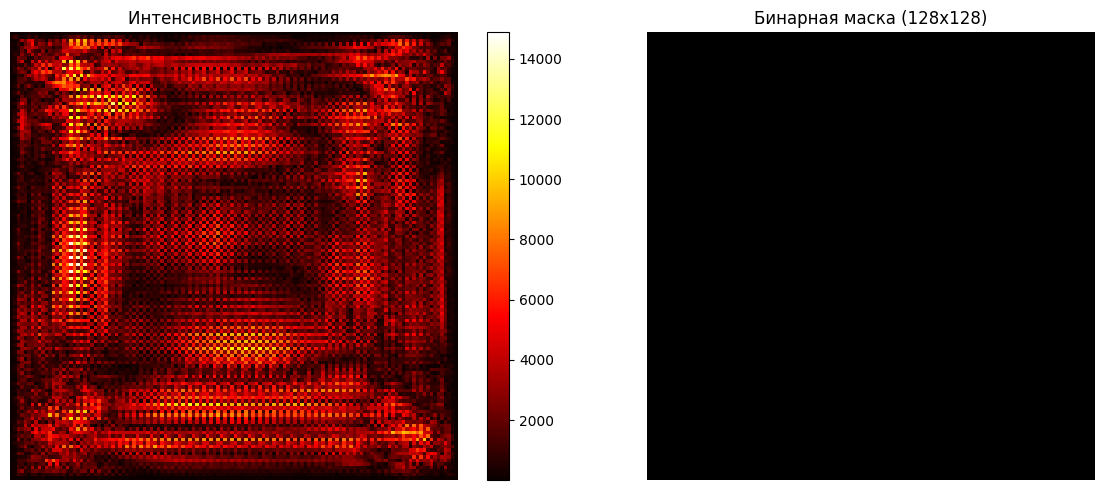

In [22]:
# Создаем большое черное изображение
img_size = 128  # меньше для быстродействия
input_img = np.zeros((1, 3, img_size, img_size))

# Вычисляем рецептивное поле
rf_size, rf_grad, rf_mask = compute_RF_numerical(model, input_img, device)
print(f"Размер рецептивного поля: {rf_size[0]}x{rf_size[1]} пикселей")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# 1. Градиент (цветом) — rf_grad уже (H, W)
im = axes[0].imshow(rf_grad, cmap='hot', interpolation='nearest')
axes[0].set_title('Интенсивность влияния')
axes[0].axis('off')
plt.colorbar(im, ax=axes[0])

# 2. Бинарная маска
axes[1].imshow(rf_mask, cmap='gray', interpolation='nearest')
axes[1].set_title(f'Бинарная маска ({rf_size[0]}x{rf_size[1]})')
axes[1].axis('off')

plt.tight_layout()
plt.show()

## Адаптация модели

Изменим выходной слой на 3 класса

In [24]:
## mobilenetv2
in_features = new_model[1].classifier[1].in_features
new_model[1].classifier[1] = nn.Linear(in_features=in_features,
                                      out_features=len(CLASSES),
                                      bias=True)

## resnet20
# in_features = new_model[1].fc.in_features
# new_model[1].fc = nn.Linear(in_features=in_features,
#                             out_features=len(CLASSES),
#                             bias=True)

new_model.to(device)
summary(new_model, input_size=(3, 32, 32))
print(new_model(torch.rand(1, 3, 32, 32).to(device)))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Normalize-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 16, 32, 32]             432
       BatchNorm2d-3           [-1, 16, 32, 32]              32
             ReLU6-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 16, 32, 32]             144
       BatchNorm2d-6           [-1, 16, 32, 32]              32
             ReLU6-7           [-1, 16, 32, 32]               0
            Conv2d-8            [-1, 8, 32, 32]             128
       BatchNorm2d-9            [-1, 8, 32, 32]              16
 InvertedResidual-10            [-1, 8, 32, 32]               0
           Conv2d-11           [-1, 48, 32, 32]             384
      BatchNorm2d-12           [-1, 48, 32, 32]              96
            ReLU6-13           [-1, 48, 32, 32]               0
           Conv2d-14           [-1, 48,

# Заморозка весов

In [25]:
print("Обучаемые параметры:")
# Сколько "размараживаем"
# -1 для всех слоев
# 2 т.к. weight + bias
keep_last = 8
total = len([*new_model.named_parameters()])
params_to_update = []

if keep_last == -1:
    # Обучаем ВСЕ параметры
    for i, (name, param) in enumerate(new_model.named_parameters()):
        param.requires_grad = True
        params_to_update.append(param)
        print("\t", name)
else:
    # Обучаем только последние keep_last слоёв
    for i, (name, param) in enumerate(new_model.named_parameters()):
        if i < total - keep_last:
            param.requires_grad = False
        else:
            params_to_update.append(param)
            param.requires_grad = True
            print("\t", name)

summary(new_model, input_size=(3, 32, 32))

Обучаемые параметры:
	 1.features.17.conv.2.weight
	 1.features.17.conv.3.weight
	 1.features.17.conv.3.bias
	 1.features.18.0.weight
	 1.features.18.1.weight
	 1.features.18.1.bias
	 1.classifier.1.weight
	 1.classifier.1.bias
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
         Normalize-1            [-1, 3, 32, 32]               0
            Conv2d-2           [-1, 16, 32, 32]             432
       BatchNorm2d-3           [-1, 16, 32, 32]              32
             ReLU6-4           [-1, 16, 32, 32]               0
            Conv2d-5           [-1, 16, 32, 32]             144
       BatchNorm2d-6           [-1, 16, 32, 32]              32
             ReLU6-7           [-1, 16, 32, 32]               0
            Conv2d-8            [-1, 8, 32, 32]             128
       BatchNorm2d-9            [-1, 8, 32, 32]              16
 InvertedResidual-10            [-1, 8, 32, 32]               0
   

# Fine tunning

In [26]:
# добавляем сглаживание целевых меток, это увеличит значение функции потерь
# но полученная модель будет более устойчивой к выбросам в обучающей выборке
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

# используется SGD c momentum и L2-регуляризацией весов
optimizer = optim.SGD(params_to_update, lr=3e-4, momentum=0.9,
                      weight_decay=1e-5)

# добавляем постепенное уменьшение шага обучения каждые 20 эпох
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

Эпоха: 60
Лучшая доля правильных ответов: 97.96401723225911
Текущая доля правильных ответов: 97.70360056559245


  0%|          | 0/720 [00:00<?, ?it/s]

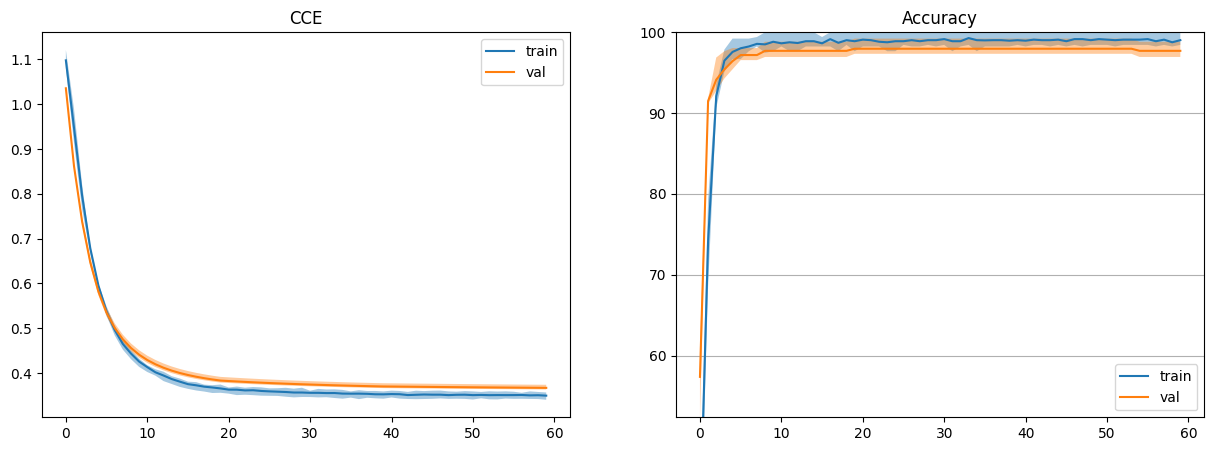

Обучение закончено за 36.85842823982239 секунд


In [27]:
EPOCHS = 60
REDRAW_EVERY = int(EPOCHS/10)

steps_per_epoch = len(dataloader['train'])
steps_per_epoch_val = len(dataloader['test'])

pbar = tqdm(total=EPOCHS*steps_per_epoch)
losses = []
losses_val = []
passed = 0

# для создания чекпоинта
best_acc = 0
checkpoint_path = 'cifar_cnn_fine.pth'

for epoch in range(EPOCHS):  # проход по набору данных несколько раз
    tmp = []
    new_model.train()
    for i, batch in enumerate(dataloader['train'], 0):
        inputs, labels = batch
        inputs, labels = inputs.to(device), labels.to(device)

        # Обучение
        optimizer.zero_grad()
        outputs = new_model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        # Статистика
        accuracy = (labels.detach().argmax(dim=-1)==outputs.detach().argmax(dim=-1)).\
                    to(torch.float32).mean().cpu()*100
        tmp.append((loss.item(), accuracy.item()))
        pbar.update(1)
    losses.append((np.mean(tmp, axis=0),
                   np.percentile(tmp, 25, axis=0),
                   np.percentile(tmp, 75, axis=0)))
    scheduler.step() # обновляем learning_rate каждую эпоху

    tmp = []
    new_model.eval()
    with torch.no_grad(): # отключение автоматического дифференцирования
        for i, data in enumerate(dataloader['test'], 0):
            inputs, labels = data
            # на GPU
            inputs, labels = inputs.to(device), labels.to(device)

            outputs = new_model(inputs)
            loss = criterion(outputs, labels)
            accuracy = (labels.argmax(dim=-1)==outputs.argmax(dim=-1)).\
                        to(torch.float32).mean().cpu()*100
            tmp.append((loss.item(), accuracy.item()))
    losses_val.append((np.mean(tmp, axis=0),
                       np.percentile(tmp, 25, axis=0),
                       np.percentile(tmp, 75, axis=0)))

    # сохранение чекпоинта
    acc = losses_val[-1][0][1]
    if acc > best_acc:
        best_acc = acc
        torch.save(new_model.state_dict(), checkpoint_path)

    # обновление графиков
    if (epoch+1) % REDRAW_EVERY != 0 and epoch != 1 and epoch != EPOCHS:
        continue
    clear_output(wait=False)

    print('Эпоха: %s\n'
          'Лучшая доля правильных ответов: %s\n'
          'Текущая доля правильных ответов: %s' % (epoch+1, best_acc, acc))
    passed += pbar.format_dict['elapsed']
    pbar = tqdm(total=EPOCHS*steps_per_epoch, miniters=5)
    pbar.update((epoch+1)*steps_per_epoch)
    x_vals = np.arange(epoch+1)
    _, ax = plt.subplots(1, 2, figsize=(15, 5))
    stats = np.array(losses)
    stats_val = np.array(losses_val)
    ax[1].set_ylim(stats_val[:, 0, 1].min()-5, 100)
    ax[1].grid(axis='y')
    for i, title in enumerate(['CCE', 'Accuracy']):
        ax[i].plot(x_vals, stats[:, 0, i], label='train')
        ax[i].fill_between(x_vals, stats[:, 1, i],
                           stats[:, 2, i], alpha=0.4)
        ax[i].plot(x_vals, stats_val[:, 0, i], label='val')
        ax[i].fill_between(x_vals,
                           stats_val[:, 1, i],
                           stats_val[:, 2, i], alpha=0.4)
        ax[i].legend()
        ax[i].set_title(title)
    plt.show()
new_model.load_state_dict(torch.load(checkpoint_path))
print('Обучение закончено за %s секунд' % passed)

# Проверка качества модели по классам на обучающей и тестовой выборках

In [28]:
dataloader = {}
for (X, y), part in zip([(train_X, train_y), (test_X, test_y)],
                        ['train', 'test']):
    tensor_x = torch.Tensor(X)
    tensor_y = F.one_hot(torch.Tensor(y).to(torch.int64),
                                     num_classes=len(CLASSES)).float()

    # Датасет без аугментации
    dataset = CifarDataset(tensor_x, tensor_y,
                           transform=None,
                           p=0.0)

    dataloader[part] = DataLoader(dataset, batch_size=batch_size, num_workers=2)

In [29]:
for part in ['train', 'test']:
    y_pred = []  # список для предсказаний модели
    y_true = []  # список для истинных меток

    with torch.no_grad():  # отключаем градиенты (экономия памяти)
        for i, data in enumerate(dataloader[part], 0):
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)  # перенос на GPU

            outputs = new_model(inputs)

            # Переносим на CPU и преобразуем в numpy
            y_pred.append(outputs.cpu().detach().numpy())
            y_true.append(labels.cpu().numpy())

    # Объединяем предсказания и метки по всем батчам
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)

    print(part)
    print(classification_report(
        y_true.argmax(axis=-1),      # true: one-hot - индексы классов
        y_pred.argmax(axis=-1),      # pred: логиты - argmax - индексы
        digits=4,
        target_names=list(map(str, CLASSES))  # подписи классов
    ))
    print('-' * 50)

train
              precision    recall  f1-score   support

           0     0.9960    0.9960    0.9960       500
          55     0.9880    0.9900    0.9890       500
          58     0.9900    0.9880    0.9890       500

    accuracy                         0.9913      1500
   macro avg     0.9913    0.9913    0.9913      1500
weighted avg     0.9913    0.9913    0.9913      1500

--------------------------------------------------
test
              precision    recall  f1-score   support

           0     1.0000    0.9900    0.9950       100
          55     0.9802    0.9900    0.9851       100
          58     0.9800    0.9800    0.9800       100

    accuracy                         0.9867       300
   macro avg     0.9867    0.9867    0.9867       300
weighted avg     0.9867    0.9867    0.9867       300

--------------------------------------------------


# Сохранение модели

In [30]:
!pip install onnx onnxscript onnxruntime

In [31]:
# Входной тензор для модели
x = torch.randn(1, 3, 32, 32, requires_grad=True).to(device)
torch_out = model(x)

# Экспорт модели
torch.onnx.export(new_model,           # модель
                  x,                   # входной тензор (или кортеж нескольких тензоров)
                  "cifar100_CNN-ft.onnx", # куда сохранить (либо путь к файлу либо fileObject)
                  export_params=True,  # сохраняет веса обученных параметров внутри файла модели
                  opset_version=18,    # версия ONNX
                  dynamo=False,        # отключает новый torch.onnx.dynamo exporter
                  do_constant_folding=True,  # следует ли выполнять укорачивание констант для оптимизации
                  input_names = ['input'],   # имя входного слоя
                  output_names = ['output'],  # имя выходного слоя
                  dynamic_axes={'input' : {0 : 'batch_size'},    # динамичные оси, в данном случае только размер пакета
                                'output' : {0 : 'batch_size'}})

/tmp/ipykernel_374/317170549.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(new_model,           # модель


In [32]:
x = torch.randn(1, 3, 32, 32, requires_grad=True).to(device)
torch_out = model(x)

# Новый экспорт (с dynamo=True)
torch.onnx.export(
    new_model,                      # модель
    x,                              # входной тензор
    "cifar100_CNN-ft-dynamo.onnx",  # путь к файлу
    export_params=True,             # сохранять веса
    opset_version=18,               # версия ONNX
    dynamo=True,                    # НОВЫЙ экспортёр (рекомендуется с PyTorch 2.9+)
    do_constant_folding=True,       # оптимизация
    input_names=['input'],          # имя входного слоя
    output_names=['output'],        # имя выходного слоя
    dynamic_shapes={                # dynamic_shapes — это словарь для dynamo=True
        'input': {0: torch.export.Dim("batch_size")}  # только для входных данных!
    }
)

print("Модель успешно экспортирована в ONNX!")

[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `Sequential([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decompositions...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
[torch.onnx] Optimize the ONNX graph... ✅
Модель успешно экспортирована в ONNX!
